R2 Before: 0.9625668449197862


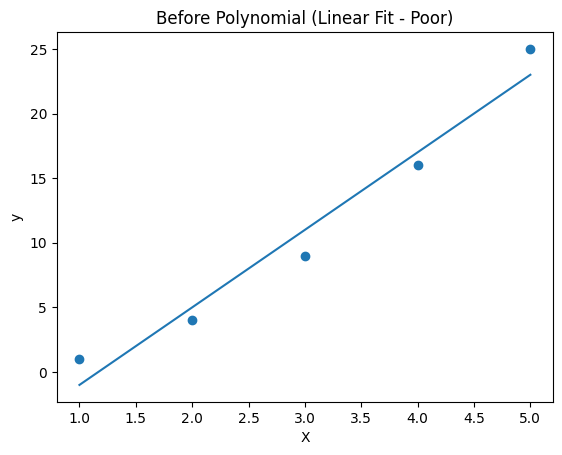

R2 After: 1.0


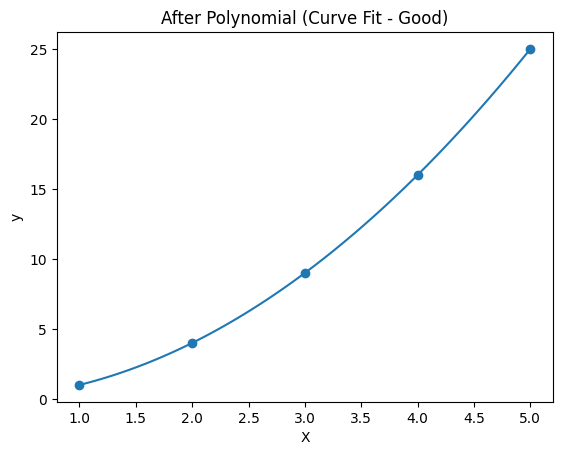

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Data (nonlinear: y = x^2)
X = np.array([1, 2, 3, 4, 5]).reshape(-1,1)
y = np.array([1, 4, 9, 16, 25])

#BEFORE (Linear Regression fails)
model = LinearRegression()
model.fit(X, y)
y_pred_before = model.predict(X)

print("R2 Before:", r2_score(y, y_pred_before))

plt.figure()
plt.scatter(X, y)
plt.plot(X, y_pred_before)
plt.title("Before Polynomial (Linear Fit - Poor)")
plt.xlabel("X")
plt.ylabel("y")
plt.show()


# ✅ AFTER (Polynomial Transformation on X)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model.fit(X_poly, y)

# Smooth curve
X_range = np.linspace(1, 5, 100).reshape(-1,1)
X_range_poly = poly.transform(X_range)
y_pred_after = model.predict(X_range_poly)

print("R2 After:", r2_score(y, model.predict(X_poly)))

plt.figure()
plt.scatter(X, y)
plt.plot(X_range, y_pred_after)
plt.title("After Polynomial (Curve Fit - Good)")
plt.xlabel("X")
plt.ylabel("y")
plt.show()